# Week 8 Hyperparameter Sweep — Run 1

## Configuration

- Backbone: EfficientNetB0
- Image size: 160 × 160
- Dropout: 0.2
- Augmentation level: Low
- Batch size: 32
- Optimizer: Adam
- Learning rate: 0.001
- Training type: Feature extraction
- Dataset: TrashNet
- Classes: Cardboard, Glass, Metal, Paper, Plastic, Trash

## Objective

This experiment is part of a six-run fractional hyperparameter sweep. Only image size, dropout, and augmentation strength are changed between runs. All other parts of the training pipeline remain fixed to ensure a fair comparison.

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
RUN_ID = 4
IMAGE_SIZE = 224
DROPOUT_RATE = 0.5
AUGMENTATION_LEVEL = "low"

BATCH_SIZE = 32
SEED = 42
EPOCHS = 20
DATASET_PATH = "/content/drive/MyDrive/data/trashnet"

In [4]:
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"Dataset folder was not found: {DATASET_PATH}"
    )

print("Dataset folder found.")
print("Folders:", sorted(os.listdir(DATASET_PATH)))

Dataset folder found.
Folders: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [5]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.


In [6]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [7]:
class_names = train_dataset.class_names

train_labels_check = np.concatenate(
    [labels.numpy() for _, labels in train_dataset]
)

validation_labels_check = np.concatenate(
    [labels.numpy() for _, labels in validation_dataset]
)

print("Class names:", class_names)
print("Training images:", len(train_labels_check))
print("Validation images:", len(validation_labels_check))
print("Training labels:", np.unique(train_labels_check))
print("Validation labels:", np.unique(validation_labels_check))

Class names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Training images: 2022
Validation images: 505
Training labels: [0 1 2 3 4 5]
Validation labels: [0 1 2 3 4 5]


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)

In [9]:
def create_augmentation(level: str) -> tf.keras.Sequential:
    level = level.lower()

    if level == "low":
        augmentation_layers = [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.1),
        ]

    elif level == "medium":
        augmentation_layers = [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.1),
            layers.RandomZoom(0.2),
            layers.RandomContrast(0.2),
        ]

    elif level == "high":
        augmentation_layers = [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.2),
            layers.RandomZoom(0.3),
            layers.RandomContrast(0.3),
            layers.RandomBrightness(0.2),
        ]

    else:
        raise ValueError(
            "AUGMENTATION_LEVEL must be 'low', 'medium', or 'high'."
        )

    return tf.keras.Sequential(
        augmentation_layers,
        name=f"{level}_augmentation"
    )


data_augmentation = create_augmentation(AUGMENTATION_LEVEL)

print("Augmentation created:", AUGMENTATION_LEVEL)

Augmentation created: low


In [10]:
tf.keras.backend.clear_session()

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(
    shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    name="input_image"
)

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.Dropout(
    DROPOUT_RATE,
    name="dropout"
)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax",
    name="predictions"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name=f"trashnet_sweep_run_{RUN_ID}"
)

model.summary()

Model: "trashnet_sweep_run_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ low_augmentation (Sequential)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled.")

Model compiled.


In [12]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [13]:
start_time = time.time()

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

end_time = time.time()

training_time_minutes = (end_time - start_time) / 60

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 209ms/step - accuracy: 0.5648 - loss: 1.1595 - val_accuracy: 0.7842 - val_loss: 0.6982 - learning_rate: 0.0010
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.7552 - loss: 0.6744 - val_accuracy: 0.8178 - val_loss: 0.5405 - learning_rate: 0.0010
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 193ms/step - accuracy: 0.8145 - loss: 0.5452 - val_accuracy: 0.8277 - val_loss: 0.4796 - learning_rate: 0.0010
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - accuracy: 0.8373 - loss: 0.4841 - val_accuracy: 0.8356 - val_loss: 0.4505 - learning_rate: 0.0010
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 162ms/step - accuracy: 0.8457 - loss: 0.4509 - val_accuracy: 0.8574 - val_loss: 0.4232 - learning_rate: 0.0010
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 166ms/step - accuracy: 0.8566 - loss: 0.4169 - val_accuracy: 0.8594 - val_loss: 0.4096 - learning_rate: 0.0010
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.8675 - loss: 0.39

In [14]:
final_train_acc = history.history["accuracy"][-1]
final_val_acc = history.history["val_accuracy"][-1]
best_history_val_acc = max(history.history["val_accuracy"])

validation_loss, restored_val_acc = model.evaluate(
    validation_dataset,
    verbose=1
)

print("=" * 45)
print(f"Run ID: {RUN_ID}")
print(f"Final Training Accuracy: {final_train_acc * 100:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc * 100:.2f}%")
print(f"Best History Validation Accuracy: {best_history_val_acc * 100:.2f}%")
print(f"Restored Model Validation Accuracy: {restored_val_acc * 100:.2f}%")
print(f"Training Time: {training_time_minutes:.2f} minutes")
print("=" * 45)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 0.8792 - loss: 0.3336
Run ID: 4
Final Training Accuracy: 90.41%
Final Validation Accuracy: 87.72%
Best History Validation Accuracy: 87.92%
Restored Model Validation Accuracy: 87.92%
Training Time: 3.85 minutes


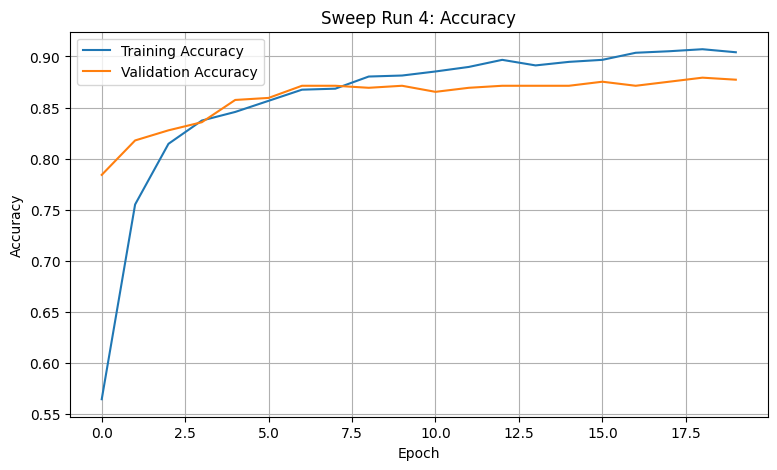

In [15]:
plt.figure(figsize=(9, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(f"Sweep Run {RUN_ID}: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

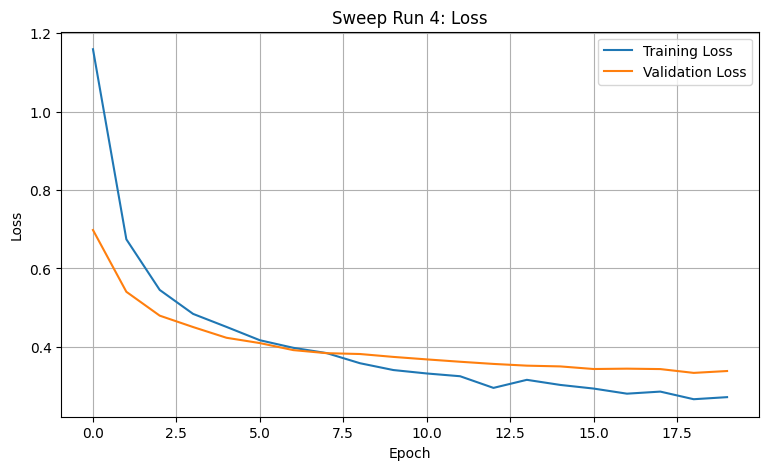

In [16]:
plt.figure(figsize=(9, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(f"Sweep Run {RUN_ID}: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
WEIGHTS_PATH = (
    f"/content/drive/MyDrive/"
    f"trashnet_sweep_run{RUN_ID}.weights.h5"
)

model.save_weights(WEIGHTS_PATH)

print("Weights saved to:", WEIGHTS_PATH)

Weights saved to: /content/drive/MyDrive/trashnet_sweep_run4.weights.h5


In [18]:
import pandas as pd

run_result = pd.DataFrame(
    [
        {
            "run_id": RUN_ID,
            "image_size": IMAGE_SIZE,
            "dropout": DROPOUT_RATE,
            "augmentation_level": AUGMENTATION_LEVEL,
            "train_acc": round(final_train_acc * 100, 2),
            "val_acc": round(restored_val_acc * 100, 2),
            "test_acc": "",
            "training_time_minutes": round(
                training_time_minutes,
                2
            ),
            "notes": "EfficientNetB0 feature extraction"
        }
    ]
)

run_result

,run_id,image_size,dropout,augmentation_level,train_acc,val_acc,test_acc,training_time_minutes,notes
0,4,224,0.5,low,90.41,87.92,,3.85,EfficientNetB0 feature extraction


In [19]:
RUN_RESULT_PATH = (
    f"/content/drive/MyDrive/"
    f"sweep_run{RUN_ID}_result.csv"
)

run_result.to_csv(
    RUN_RESULT_PATH,
    index=False
)

print("Run result saved to:", RUN_RESULT_PATH)

Run result saved to: /content/drive/MyDrive/sweep_run4_result.csv
